检验数据形状

In [4]:
import pandas as pd

file_path = r"C:\Users\35336\Desktop\Data1.xlsx"
data = pd.read_excel(file_path, sheet_name="data", header=0)
print(data.shape)
print(data.columns.tolist())

(38692, 16)
['CH0', 'CH1', 'CH2', 'CH3', 'CH4', 'CH5', 'CH6', 'CH7', 'CH8', 'CH9', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'CH15']


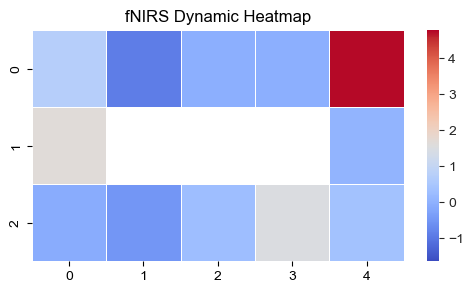

In [5]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation

# ------------------------------
# 1️⃣ 读取数据
# ------------------------------
file_path = r"C:\Users\35336\Desktop\Data1.xlsx"
data = pd.read_excel(file_path, sheet_name="data", header=0)

# 只使用 CH1~CH12
used_ch = [f"CH{i}" for i in range(1,13)]
data = data[used_ch]

# 取前 1000 行测试动画
data_sample = data.iloc[:1000, :]

# ------------------------------
# 2️⃣ 矩阵布局
# ------------------------------
matrix_layout = np.array([
    ["CH6",  "CH5", "CH4", "CH3", "CH2"],
    ["CH12", None,  None,  None, "CH1"],
    ["CH11", "CH10","CH9", "CH8", "CH7"]
], dtype=object)

# ------------------------------
# 3️⃣ 映射函数
# ------------------------------
def get_signal_matrix(ch_row):
    ch_values = {ch: float(val) for ch, val in zip(used_ch, ch_row.values)}
    sig_matrix = np.vectorize(lambda x: ch_values.get(x, np.nan) if x is not None else np.nan)(matrix_layout)
    return sig_matrix

# ------------------------------
# 4️⃣ 设置动画
# ------------------------------
fig, ax = plt.subplots(figsize=(6,3))
sns.set_style("white")

# 初始热图（第一帧）
sig_matrix = get_signal_matrix(data_sample.iloc[0])
heatmap = sns.heatmap(sig_matrix, annot=False, fmt=".2f", cmap="coolwarm",
                      cbar=True, linewidths=0.5, ax=ax, vmin=data_sample.min().min(), vmax=data_sample.max().max())
plt.title("fNIRS Dynamic Heatmap")

# 更新函数
def update(frame):
    ax.clear()
    sig_matrix = get_signal_matrix(data_sample.iloc[frame])
    sns.heatmap(sig_matrix, annot=False, fmt=".2f", cmap="coolwarm",
                cbar=True, linewidths=0.5, ax=ax, vmin=data_sample.min().min(), vmax=data_sample.max().max())
    ax.set_title(f"Time Point {frame+1}")

# 创建动画
ani = FuncAnimation(fig, update, frames=len(data_sample), interval=50)  # interval 毫秒

# 显示动画
plt.show()

# 如果想保存为 mp4 视频：
# ani.save("fnirs_dynamic.mp4", writer="ffmpeg", fps=20)